<a href="https://colab.research.google.com/github/Joaoplims/NLP-HandsOn/blob/main/HO02/HO02_NLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Relatório Final:**
Para este Hands On, pegamos um corpus relativamente pequeno contendo manchetes de noticias. O corpus foi fornecido a partir de um documento chamado headlines.txt.

# **Primeiro Passo:**
A estrutura do arquivo headlines.txt é composta por 10 linhas, cada uma contendo o texto de uma manchete diferente. Todas as manchetes são relacionadas a temas como criptomoedas e cripto currency. Após ler o arquivo, armazenamos cada manchete em um array chamado headlines.

# **Segundo Passo:**
Com os textos devidamentes armazenados, passamos o conteudo de cada manchete em uma pipeline de normalização composta pelos passos de remoção de acentos e caracteres especiais, tokenização, lematização e stemming. Este passo é extremamente necessário para que tenhamos as palavras tratadas para as operações dos passos seguintes.

# **Terceiro Passo:**
Após normalizar os textos, salvamos cada token normalizado em um conjunto chamado ***vocabulary***. O intuito aqui é extrair todo o vocabulário identificado no corpus do documento lido (headlines.txt). Este passo é importante, pois com a construção do vocabulário bem sucessidida, conseguimos criar as representações vetoriais. O tamanho total do vocabulario foi de *84 palavras únicas*. O vocabulario foi então ordenado alfabeticamente

# **Quarto Passo:**
Com o ***vocabulary*** construido, criamos a primeira representação vetórial: a representação *One-Hot*. Esta representação consiste em criar um vetor de dimensão = len(vocabulary), ou seja, um vetor com 84 posições. Dessa forma, a palavra 'a', presente na posição 1 do vocabulário, foi transformada no vetor [1,0,0,0,0,0,0,0,0,0,0,0,...].

A representação vetorial One-Hot é muito simples, permite que possamos fazer algumas operações básicas, mas não nos fornece nenhuma informação sobre relação semantica das palavras codificadas. Além disso, cria um vetor muito esparso, o que é ruim para armazenar, fazer operações e visualizar, mesmo em um corpus pequeno como o corpus do arquivo headlines.txt

# **Quinto Passo:**
Criamos a representação *counting vector*. Esta representação é muito similar ao One-Hot, a diferença é que ele conta contas vezes o token repete dentro do documento. Com ele, conseguimos coletar informações de palavras importantes dentro do texto, mas é uma informação bastante ruidosa pois stop words existem dentro do documento lido, e portanto, gera um ruido para identificar palavras que são realmente importantes dentro do contexto do corpus.

# **Sexto Passo:**
Criams a representação **TF-IDF**. Esta representação consiste em destacar palavras que são frequentes em um documento específico, mas raras no restante do conjunto de dados. Esta representação nos ajuda a identificar palavras importantes semanticamente pois consegue reduzir o ruido causado pela representação *couting vector*

# **Sétimo Passo:**
Criamos a representação chamada de **Matriz de Co-ocorrencia/Vetor de Co-ocorrencia**. Este passo foi bastante desafiador pois tive que fazer uma pesquisa para entender melhor do que se trata e confesso que nao entendi muito bem a lógica... Mas pelo o que entendi, diferente das representações anteriores, ela não foca apenas na presença da palavra no documento, mas sim em quais palavras aparecem juntas em uma vizinhança (janela de contexto). Ela consiste em uma matriz N x N (onde N é o tamanho do vocabulário), em que cada célula registra a frequência com que dois termos aparecem próximos. É fundamental para captar relações semânticas (como 'bitcoin' aparecendo perto de 'bank'), mas como ponto negativo e que este método gera matrizes gigantescas e muito esparsas em grandes volumes de dados, exigindo alto poder computacional (O(n²))."

# **Oitavo Passo:**
Criamos a representação **Word2Vec**. É um método muito mais robusto que implementa um algoritmo de aprendizado para criar uma representação vetórial dos tokens. Diferentemente dos outros métodos, os vetores gerados são DENSOS e RICOS SEMANTICAMENTE o que é muito bom para entendermos similaridades entre termos. A parte ruim é que, por se tratar de um algoritmo de aprendizado de máquina que utiliza uma abordagem probabilistica, a lógica para gerar estes vetores é um pouco nebulosa para nós humanos e o que o algoritmo aprende pode ser de dificil compreensão. Entretanto, conforme visto no Nono passo, o algoritmo foi bem eficiente em deduzir a relação entre os tokens mesmo em um corpus bem pequeno. Mas uma observação importante é que devido ou corpus pequeno e a definição dos hiperparametros feitas por mim, acredito que os vetores gerados nao foram os mais eficientes.

Utilizei tanto a abordagem CBOW quanto a abordagem SkipGram e ambos geraram resultados bem parecidos

# **Nono Passo:**
Utilizando a presentação vetorial Word2Vec e a representação vetorial de Vetores de Co-ocorrencia, foi calculado a similaridade euclidiana e simlaridade de cossenos. Como tudo é vetor(mesmo que sejam N Dimensionais), podemos aplicar operações de algebra linear neles e com isso entender se um vetor está proximo (distancia euclidiana) ou se estão alinhados (Similaridade de cossenos).
## Para distancia euclidiana
Valores proximos de 0 indicam que as palavras são proximas semanticamente
## Para Similaridade de Cossenos
Valores proximos de 1 indicam que as palavras estão alinhadas, e portanto, são similares

O resultado dos vetores Word2Vec foi muito mais coerente neste passo




In [4]:
import requests
import os

# URL do arquivo TXT no GitHub
github_txt_url = "https://raw.githubusercontent.com/Joaoplims/NLP-HandsOn/refs/heads/main/HO02/headlines.txt"
local_txt_path = "/tmp/headlines.txt" # Salva o arquivo TXT em um caminho temporário

print(f"Tentando baixar o arquivo do GitHub: {github_txt_url}")

try:
    response = requests.get(github_txt_url)
    response.raise_for_status() # Levanta um HTTPError para respostas de status de erro (4xx ou 5xx)

    with open(local_txt_path, 'wb') as f:
        f.write(response.content)
    print(f"Arquivo baixado e salvo localmente em: {local_txt_path}\n")

except requests.exceptions.RequestException as e:
    print(f"Erro ao baixar o arquivo: {e}")
    print("Por favor, verifique se a URL do GitHub está correta e o arquivo existe.")

# Este célula pode ser usado para verificar a existência do arquivo.
if os.path.exists('/tmp/headlines.txt'):
    print(f"Arquivo headlines.txt encontrado em: /tmp/headlines.txt")
else:
    print(f"Arquivo headlines.txt NÃO encontrado em: /tmp/headlines.txt. Verifique o download.")

Tentando baixar o arquivo do GitHub: https://raw.githubusercontent.com/Joaoplims/NLP-HandsOn/refs/heads/main/HO02/headlines.txt
Arquivo baixado e salvo localmente em: /tmp/headlines.txt

Arquivo headlines.txt encontrado em: /tmp/headlines.txt


In [5]:
file_path = '/tmp/headlines.txt'

headlines = []

try:
    with open(file_path, 'r', encoding='utf-8') as f:
        for line in f:
            headlines.append(line.strip()) # .strip() removes leading/trailing whitespace, including newline characters
    print(f"Successfully read {len(headlines)} headlines from '{file_path}'.")
    print("\nFirst 5 headlines:")
    for i, headline in enumerate(headlines[:5]):
        print(f"{i+1}. {headline}")
except FileNotFoundError:
    print(f"Error: The file '{file_path}' was not found in the current directory ({os.getcwd()}). Please check the file path.")
except Exception as e:
    print(f"An error occurred while reading the file: {e}")

Successfully read 10 headlines from '/tmp/headlines.txt'.

First 5 headlines:
1. Investors unfazed by correction as crypto funds see $154 million inflows
2. Bitcoin, Ethereum prices continue descent, but crypto funds see inflows
3. The surge in euro area inflation during the pandemic: transitory but with upside risks
4. Inflation: why it's temporary and raising interest rates will do more harm than good
5. Will Cryptocurrency Protect Against Inflation?


### Text Normalization Pipeline

1.  **Remove caracteres especiais**
2.  **Tokenization**
3.  **Lemmatization**
4.  **Stemming**

In [4]:
# Install necessary libraries
!pip install unidecode

# Download NLTK data
import nltk
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('punkt_tab')
# Removed: nltk.download('rslp') as it's for Portuguese
# Download Scikit-Learn
!pip install -U scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.8/235.8 kB 5.2 MB/s eta 0:00:00


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 56.2 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1


In [6]:
import re
from unidecode import unidecode
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer, PorterStemmer

# Initialize lemmatizer and stemmer
lemmatizer = WordNetLemmatizer()
stemmer = PorterStemmer()

def normalize_text(text):
    # 1. Remove accents and special characters
    text = unidecode(text) # Remove accents
    text = re.sub(r'[^a-zA-Z\s]', '', text) # Remove special characters, keep letters and spaces
    text = text.lower() # Convert to lowercase

    # 2. Tokenization
    tokens = word_tokenize(text)

    # 3. Lemmatization (using English WordNetLemmatizer)
    lemmas = [lemmatizer.lemmatize(word) for word in tokens]

    # 4. Stemming (using English PorterStemmer)
    stemmed_tokens = [stemmer.stem(word) for word in lemmas] # Apply stemming after lemmatization

    return stemmed_tokens

print("Text normalization function 'normalize_text' created successfully.")

Text normalization function 'normalize_text' created successfully.


#### Demonstration of the `normalize_text` function

In [7]:
example_headline = headlines[2] # Using the third headline for demonstration
print(f"Original headline: {example_headline}")

normalized_example = normalize_text(example_headline)
print(f"Normalized headline: {normalized_example}")

Original headline: The surge in euro area inflation during the pandemic: transitory but with upside risks
Normalized headline: ['the', 'surg', 'in', 'euro', 'area', 'inflat', 'dure', 'the', 'pandem', 'transitori', 'but', 'with', 'upsid', 'risk']


In [8]:
# Criar um novo vetor com todas as manchetes normalizadas
all_normalized_documents = [normalize_text(headline) for headline in headlines]

print(f"Sucesso! Criado o vetor 'all_normalized_documents' com {len(all_normalized_documents)} documentos.")

# Demonstrar os primeiros 5 documentos normalizados
print("\nPrimeiros 5 documentos normalizados:")
for i, doc in enumerate(all_normalized_documents[:10]):
    print(f"{i+1}: {doc}")

Sucesso! Criado o vetor 'all_normalized_documents' com 10 documentos.

Primeiros 5 documentos normalizados:
1: ['investor', 'unfaz', 'by', 'correct', 'a', 'crypto', 'fund', 'see', 'million', 'inflow']
2: ['bitcoin', 'ethereum', 'price', 'continu', 'descent', 'but', 'crypto', 'fund', 'see', 'inflow']
3: ['the', 'surg', 'in', 'euro', 'area', 'inflat', 'dure', 'the', 'pandem', 'transitori', 'but', 'with', 'upsid', 'risk']
4: ['inflat', 'whi', 'it', 'temporari', 'and', 'rais', 'interest', 'rate', 'will', 'do', 'more', 'harm', 'than', 'good']
5: ['will', 'cryptocurr', 'protect', 'against', 'inflat']
6: ['tweed', 'is', 'a', 'crypto', 'wallet', 'api', 'to', 'add', 'a', 'web', 'flavor', 'to', 'ani', 'web', 'servic']
7: ['who', 'creat', 'bitcoin', 'learn', 'about', 'the', 'biggest', 'crypto', 'includ', 'dogecoin', 'big', 'eye', 'coin']
8: ['cryptocurr', 'price', 'and', 'news', 'bitcoin', 'crypto', 'fall', 'after', 'silverg', 'bank', 'liquid', 'news']
9: ['silverg', 'capit', 'to', 'shut', 'down'

In [9]:
def build_vocabulary(documents):
    """
    Gera um vocabulário único e ordenado a partir de uma lista de documentos (listas de tokens).
    """
    vocab = set()
    for doc in documents:
        for word in doc:
            vocab.add(word)

    return sorted(list(vocab))

# Gerar o vocabulário a partir do vetor de documentos normalizados
vocabulary = build_vocabulary(all_normalized_documents)

print(f"Vocabulário criado com {len(vocabulary)} palavras únicas.")
print(vocabulary[:85])

Vocabulário criado com 84 palavras únicas.
['a', 'about', 'add', 'after', 'against', 'and', 'ani', 'api', 'area', 'bank', 'big', 'biggest', 'bitcoin', 'but', 'by', 'capit', 'claim', 'coin', 'continu', 'correct', 'crash', 'creat', 'crypto', 'cryptocurr', 'cryptofriendli', 'descent', 'do', 'dogecoin', 'dow', 'down', 'drop', 'dure', 'ethereum', 'euro', 'eye', 'fall', 'flavor', 'fund', 'good', 'harm', 'in', 'includ', 'inflat', 'inflow', 'interest', 'investor', 'is', 'it', 'jobless', 'jone', 'jump', 'learn', 'liquid', 'million', 'more', 'news', 'on', 'pandem', 'price', 'protect', 'rais', 'rate', 'rise', 'risk', 'see', 'servic', 'shut', 'silverg', 'surg', 'surpris', 'temporari', 'than', 'the', 'to', 'transitori', 'tweed', 'unfaz', 'upsid', 'wallet', 'web', 'whi', 'who', 'will', 'with']


In [10]:
import numpy as np

# 1. Criar um mapeamento de palavra para ndice
word_to_idx = {word: i for i, word in enumerate(vocabulary)}
vocab_size = len(vocabulary)

def get_one_hot(word):
    """
    Gera o vetor one-hot para uma palavra especfica baseada no vocabulrio.
    Usamos dtype=int para garantir que os valores sejam 0 e 1 inteiros.
    """
    vector = np.zeros(vocab_size, dtype=int)
    if word in word_to_idx:
        idx = word_to_idx[word]
        vector[idx] = 1
    return vector

# 2. Demonstrao
print(f"{'Palavra':<15} - {'Pos':<3} - {'Representacaoo One-Hot'}")
print('-' * 60)

# Demonstrando para as primeiras 10 palavras do vocabulrio
for word in vocabulary[:10]:
    idx = word_to_idx[word]
    # Convertendo para lista Python comum para uma visualizao limpa [0, 1, 0...]
    one_hot = get_one_hot(word).tolist()

    # Mostrando apenas uma parte do vetor para no poluir a tela
    vector_str = str(one_hot[:15]).replace(']', ', ...]')
    print(f"{word:<15} - {idx:<3} - {vector_str}")

Palavra         - Pos - Representacaoo One-Hot
------------------------------------------------------------
a               - 0   - [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...]
about           - 1   - [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...]
add             - 2   - [0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...]
after           - 3   - [0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...]
against         - 4   - [0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...]
and             - 5   - [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...]
ani             - 6   - [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, ...]
api             - 7   - [0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, ...]
area            - 8   - [0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, ...]
bank            - 9   - [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, ...]


### Representação por Counting Vectors (Term Frequency)

Agora, vamos implementar a função que gera o vetor de contagem para um documento inteiro. Diferente do One-Hot (que indica apenas presença/ausência), o Counting Vector reflete a frequência de cada termo.

In [11]:
def get_counting_vector(normalized_doc, vocabulary, word_to_idx):
    """
    Gera um vetor de contagem para um documento baseado no vocabulário.
    """
    vocab_size = len(vocabulary)
    vector = np.zeros(vocab_size, dtype=int)

    for word in normalized_doc:
        if word in word_to_idx:
            idx = word_to_idx[word]
            vector[idx] += 1 # Incrementa a contagem

    return vector

print("Função 'get_counting_vector' criada com sucesso.")

Função 'get_counting_vector' criada com sucesso.


#### Demonstração com uma manchete real
Vamos usar a terceira manchete (`headlines[2]`), que contém a palavra "the" repetida, para observar a contagem no vetor.

In [12]:
idx_demo = 2
doc_demo = all_normalized_documents[idx_demo]
counting_vector = get_counting_vector(doc_demo, vocabulary, word_to_idx)

print(f"Documento original: {headlines[idx_demo]}")
print(f"Documento normalizado: {doc_demo}")

# 1. Mostrar o vetor COMPLETO para visualização total
print(f"\nRepresentação Counting Vector Completa (Vocabulário de {len(vocabulary)} palavras):")
print(counting_vector.tolist())

# 2. Validar especificamente a palavra 'the'
word_to_check = 'the'
idx_the = word_to_idx[word_to_check]
count_the = counting_vector[idx_the]

print(f"\nValidação:")
print(f"Palavra: '{word_to_check}' | Índice no Vocabulário: {idx_the} | Valor no Vetor: {count_the}")

# 3. Mostrar quais índices estão ativos (diferentes de zero)
print("\nÍndices ativos no vetor (Palavra: Frequência):")
for word in set(doc_demo):
    idx = word_to_idx[word]
    count = counting_vector[idx]
    print(f"- Índice {idx:2} ({word:<12}): {count}")

Documento original: The surge in euro area inflation during the pandemic: transitory but with upside risks
Documento normalizado: ['the', 'surg', 'in', 'euro', 'area', 'inflat', 'dure', 'the', 'pandem', 'transitori', 'but', 'with', 'upsid', 'risk']

Representação Counting Vector Completa (Vocabulário de 84 palavras):
[0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 2, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1]

Validação:
Palavra: 'the' | Índice no Vocabulário: 72 | Valor no Vetor: 2

Índices ativos no vetor (Palavra: Frequência):
- Índice 57 (pandem      ): 1
- Índice 72 (the         ): 2
- Índice  8 (area        ): 1
- Índice 31 (dure        ): 1
- Índice 13 (but         ): 1
- Índice 77 (upsid       ): 1
- Índice 40 (in          ): 1
- Índice 42 (inflat      ): 1
- Índice 74 (transitori  ): 1
- Índice 33 (euro        ): 1
- Índ

### Representação TF-IDF (Term Frequency - Inverse Document Frequency)

O TF-IDF ajuda a destacar palavras que são frequentes em um documento específico, mas raras no restante do conjunto de dados.

In [13]:
import math

def compute_idf(documents, vocabulary):
    """
    Calcula o valor IDF para cada palavra no vocabulário.
    IDF = log(Total de documentos / Documentos que contêm a palavra)
    """
    N = len(documents)
    idf_dict = {}

    for word in vocabulary:
        # Contar em quantos documentos a palavra aparece
        docs_with_word = sum(1 for doc in documents if word in doc)
        # Usamos log natural. Somamos 1 ao denominador para evitar divisão por zero (smooth_idf)
        idf_dict[word] = math.log(N / (docs_with_word))

    return idf_dict

def get_tfidf_vector(normalized_doc, vocabulary, word_to_idx, idf_dict):
    """
    Gera o vetor TF-IDF para um documento.
    """
    vocab_size = len(vocabulary)
    vector = np.zeros(vocab_size, dtype=float)

    # Pegamos as contagens (TF)
    counts = get_counting_vector(normalized_doc, vocabulary, word_to_idx)

    for word in set(normalized_doc):
        if word in word_to_idx:
            idx = word_to_idx[word]
            tf = counts[idx]
            idf = idf_dict[word]
            vector[idx] = tf * idf

    return vector

# 1. Calcular o IDF global baseado em todas as nossas manchetes
idf_values = compute_idf(all_normalized_documents, vocabulary)

print("Valores IDF calculados com sucesso.")

Valores IDF calculados com sucesso.


#### Demonstração do TF-IDF
Vamos comparar o peso da palavra 'the' (muito comum) com palavras mais específicas na mesma manchete.

In [14]:
idx_demo = 2
doc_demo = all_normalized_documents[idx_demo]
tfidf_vector = get_tfidf_vector(doc_demo, vocabulary, word_to_idx, idf_values)

print(f"Documento: {headlines[idx_demo]}\n")
print(f"{'Palavra':<12} | {'Count (TF)':<10} | {'IDF':<8} | {'TF-IDF':<8}")
print("-" * 50)

# Exibir os valores para algumas palavras da manchete
for word in sorted(set(doc_demo)):
    idx = word_to_idx[word]
    tf = get_counting_vector(doc_demo, vocabulary, word_to_idx)[idx]
    idf = idf_values[word]
    tfidf = tfidf_vector[idx]
    print(f"{word:<12} | {tf:<10} | {idf:.4f} | {tfidf:.4f}")

print(f"\nVetor TF-IDF completo (primeiras 20 posições):\n{tfidf_vector[:20].tolist()}")

Documento: The surge in euro area inflation during the pandemic: transitory but with upside risks

Palavra      | Count (TF) | IDF      | TF-IDF  
--------------------------------------------------
area         | 1          | 2.3026 | 2.3026
but          | 1          | 1.6094 | 1.6094
dure         | 1          | 2.3026 | 2.3026
euro         | 1          | 2.3026 | 2.3026
in           | 1          | 1.6094 | 1.6094
inflat       | 1          | 1.2040 | 1.2040
pandem       | 1          | 2.3026 | 2.3026
risk         | 1          | 2.3026 | 2.3026
surg         | 1          | 2.3026 | 2.3026
the          | 2          | 1.6094 | 3.2189
transitori   | 1          | 2.3026 | 2.3026
upsid        | 1          | 2.3026 | 2.3026
with         | 1          | 2.3026 | 2.3026

Vetor TF-IDF completo (primeiras 20 posições):
[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 2.302585092994046, 0.0, 0.0, 0.0, 0.0, 1.6094379124341003, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]


### Matriz de Co-ocorrência (Janela de Contexto)

A co-ocorrência mede quantas vezes duas palavras aparecem próximas uma da outra dentro de uma janela definida (neste caso, 1 vizinho à esquerda e 1 à direita).

In [15]:
from collections import defaultdict
import numpy as np

# 1. Verificar se os documentos normalizados existem
if 'all_normalized_documents' in globals():
    # 2. Criar um dicionário de dicionários para armazenar as contagens
    coocorrencias = defaultdict(lambda: defaultdict(int))

    # 3. Percorrer cada documento normalizado
    for doc in all_normalized_documents:
        for i, alvo in enumerate(doc):
            # Identificar vizinhos (janela de 1)
            # Vizinho à esquerda (se existir)
            if i > 0:
                vizinho_esq = doc[i-1]
                coocorrencias[alvo][vizinho_esq] += 1

            # Vizinho à direita (se existir)
            if i < len(doc) - 1:
                vizinho_dir = doc[i+1]
                coocorrencias[alvo][vizinho_dir] += 1

    print(f"Matriz de co-ocorrência construída com sucesso usando {len(all_normalized_documents)} documentos!")
else:
    print("Erro: A variável 'all_normalized_documents' não foi encontrada. Por favor, execute a célula 'e212158f' antes desta.")

Matriz de co-ocorrência construída com sucesso usando 10 documentos!


#### Demonstração de Co-ocorrência
Vamos ver quais palavras mais co-ocorrem com termos chave como 'bitcoin' ou 'crypto'.

In [16]:
def show_cooccurrences(word):
    if word in coocorrencias:
        print(f"Palavras que aparecem ao lado de '{word}':")
        # Ordenar pelos vizinhos mais frequentes
        vizinhos_ordenados = sorted(coocorrencias[word].items(), key=lambda x: x[1], reverse=True)
        for vizinho, count in vizinhos_ordenados:
            print(f"- {vizinho:<12}: {count} vezes")
    else:
        print(f"A palavra '{word}' não foi encontrada ou não possui vizinhos.")

# Testando com algumas palavras do nosso corpus
show_cooccurrences('bitcoin')
print("-" * 30)
show_cooccurrences('crypto')

Palavras que aparecem ao lado de 'bitcoin':
- ethereum    : 1 vezes
- creat       : 1 vezes
- learn       : 1 vezes
- news        : 1 vezes
- crypto      : 1 vezes
- claim       : 1 vezes
- drop        : 1 vezes
------------------------------
Palavras que aparecem ao lado de 'crypto':
- a           : 3 vezes
- fund        : 2 vezes
- but         : 1 vezes
- wallet      : 1 vezes
- biggest     : 1 vezes
- includ      : 1 vezes
- bitcoin     : 1 vezes
- fall        : 1 vezes
- bank        : 1 vezes


### Implementação de Word2Vec (CBOW e Skip-gram)

Utilizaremos a biblioteca `gensim` para transformar nossas palavras em vetores densos (embeddings).

**Parâmetros utilizados:**
- `vector_size=50`: Cada palavra será representada por um vetor de 50 dimensões.
- `window=5`: O contexto considerará 5 palavras vizinhas.
- `min_count=1`: Não descartaremos palavras por baixa frequência, dado o tamanho reduzido do corpus.
- `sg`: Define o algoritmo (0 para CBOW, 1 para Skip-gram).

In [17]:
# Instalar biblioteca necessária
!pip install gensim

from gensim.models import Word2Vec

# 1. Função para treinar usando CBOW (sg=0)
def train_cbow(docs):
    model = Word2Vec(sentences=docs, vector_size=50, window=5, min_count=1, sg=0, workers=4)
    return model

# 2. Função para treinar usando Skip-gram (sg=1)
def train_skipgram(docs):
    model = Word2Vec(sentences=docs, vector_size=50, window=5, min_count=1, sg=1, workers=4)
    return model

# Gerando e armazenando os resultados em variáveis diferentes
model_cbow = train_cbow(all_normalized_documents)
model_skipgram = train_skipgram(all_normalized_documents)

print("Modelos Word2Vec (CBOW e Skip-gram) gerados e armazenados com sucesso!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 60.5 MB/s eta 0:00:00
Modelos Word2Vec (CBOW e Skip-gram) gerados e armazenados com sucesso!


#### Exploração Inicial dos Vetores
Vamos visualizar o vetor gerado para a palavra 'bitcoin' em ambos os modelos.

In [18]:
palavra_teste = 'bitcoin'

print(f"Vetor de '{palavra_teste}' no modelo CBOW:")
print(model_cbow.wv[palavra_teste])

print(f"\nVetor de '{palavra_teste}' no modelo Skip-gram:")
print(model_skipgram.wv[palavra_teste])

# Exemplo de busca por similaridade no CBOW
print(f"\nPalavras mais similares a '{palavra_teste}' no CBOW:")
display(model_cbow.wv.most_similar(palavra_teste, topn=5))
# Exemplo de busca por similaridade no Skip-gram
print(f"\nPalavras mais similares a '{palavra_teste}' no Skip-gram:")
display(model_skipgram.wv.most_similar(palavra_teste, topn=5))

Vetor de 'bitcoin' no modelo CBOW:
[-0.01722436  0.0073385   0.01038028  0.0114864   0.0149234  -0.01233635
  0.00221199  0.01211565 -0.00567309 -0.01236021 -0.00082182 -0.01674785
 -0.01119509  0.01422798  0.00668608  0.01445428  0.01360311  0.01506952
 -0.00758901 -0.00111136  0.00469514 -0.0090262   0.01678199 -0.01970989
  0.01353228  0.00582948 -0.00986529  0.00880505 -0.00348085  0.01342793
  0.01991367 -0.00872883 -0.0012012  -0.01139779  0.00769312  0.00558254
  0.01378616  0.01219773  0.01908217  0.0185571   0.01580409 -0.01398703
 -0.0183125  -0.00071867 -0.00618595  0.01578381  0.01187113 -0.00309866
  0.00302655  0.00357517]

Vetor de 'bitcoin' no modelo Skip-gram:
[-0.01723018  0.00729765  0.01035043  0.01148347  0.01493112 -0.01231979
  0.00220222  0.01211338 -0.00568406 -0.01236336 -0.00084234 -0.01677981
 -0.0111451   0.01425521  0.0066594   0.01447824  0.01360582  0.01509123
 -0.00760685 -0.00113268  0.00473817 -0.00904441  0.01677582 -0.01974108
  0.01351557  0.005825

[('with', 0.3408934772014618),
 ('it', 0.32600295543670654),
 ('million', 0.28945398330688477),
 ('coin', 0.250986784696579),
 ('fall', 0.24869656562805176)]


Palavras mais similares a 'bitcoin' no Skip-gram:


[('with', 0.3412168323993683),
 ('it', 0.32629498839378357),
 ('million', 0.2894674241542816),
 ('coin', 0.2516915500164032),
 ('fall', 0.24915993213653564)]

### Cálculo de Similaridade Par-a-Par

Agora vamos comparar duas palavras específicas ('bitcoin' e 'crypto') usando as métricas:
- **Cosine Similarity**: Foca no ângulo entre os vetores (1.0 é identidade).
- **Euclidean Distance**: Foca na distância geométrica entre os pontos (0.0 é identidade).

In [19]:
from sklearn.metrics.pairwise import cosine_similarity
from scipy.spatial.distance import euclidean
import numpy as np

def calculate_metrics(model, w1, w2, model_name):
    v1 = model.wv[w1].reshape(1, -1)
    v2 = model.wv[w2].reshape(1, -1)

    # Cosine Similarity
    cos_sim = cosine_similarity(v1, v2)[0][0]

    # Euclidean Distance
    euc_dist = euclidean(v1.flatten(), v2.flatten())

    print(f"--- Métricas no modelo {model_name} ---")
    print(f"Palavras: '{w1}' e '{w2}'")
    print(f"Similaridade de Cosseno: {cos_sim:.4f}")
    print(f"Distância Euclidiana:    {euc_dist:.4f}\n")

word_a = 'bitcoin'
word_b = 'crypto'

calculate_metrics(model_cbow, word_a, word_b, "CBOW")
calculate_metrics(model_skipgram, word_a, word_b, "Skip-gram")

--- Métricas no modelo CBOW ---
Palavras: 'bitcoin' e 'crypto'
Similaridade de Cosseno: 0.1271
Distância Euclidiana:    0.1115

--- Métricas no modelo Skip-gram ---
Palavras: 'bitcoin' e 'crypto'
Similaridade de Cosseno: 0.1280
Distância Euclidiana:    0.1115



### Cálculo de Similaridade usando a Matriz de Co-ocorrência

Como a nossa matriz de co-ocorrência está armazenada em um dicionário de dicionários (`defaultdict`), precisamos primeiro converter a representação de duas palavras específicas em vetores numéricos alinhados ao nosso vocabulário global para calcular as métricas.

In [20]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from scipy.spatial.distance import euclidean

# Garantindo que o mapeamento existe
word_to_idx = {word: i for i, word in enumerate(vocabulary)}

def get_cooccurrence_vector(word, vocabulary, cooccur_dict, word_to_idx_map):
    vector = np.zeros(len(vocabulary))
    if word in cooccur_dict:
        for neighbor, count in cooccur_dict[word].items():
            if neighbor in word_to_idx_map:
                idx = word_to_idx_map[neighbor]
                vector[idx] = count
    return vector

def calculate_cooccurrence_metrics(w1, w2, vocabulary, cooccur_dict, word_to_idx_map):
    v1 = get_cooccurrence_vector(w1, vocabulary, cooccur_dict, word_to_idx_map).reshape(1, -1)
    v2 = get_cooccurrence_vector(w2, vocabulary, cooccur_dict, word_to_idx_map).reshape(1, -1)

    if np.all(v1 == 0) or np.all(v2 == 0):
        cos_sim = 0.0
    else:
        cos_sim = cosine_similarity(v1, v2)[0][0]

    euc_dist = euclidean(v1.flatten(), v2.flatten())

    print(f"--- Métricas na Matriz de Co-ocorrência ---")
    print(f"Palavras: '{w1}' e '{w2}'")
    print(f"Similaridade de Cosseno: {cos_sim:.4f}")
    print(f"Distância Euclidiana:    {euc_dist:.4f}\n")

calculate_cooccurrence_metrics(word_a, word_b, vocabulary, coocorrencias, word_to_idx)

--- Métricas na Matriz de Co-ocorrência ---
Palavras: 'bitcoin' e 'crypto'
Similaridade de Cosseno: 0.0000
Distância Euclidiana:    5.1962



### Visualização de Similaridade Documento-Documento

Nesta seção, compararemos como os 10 documentos se agrupam usando diferentes representações textuais e métricas de distância.

Matrizes para Counting Vectors:


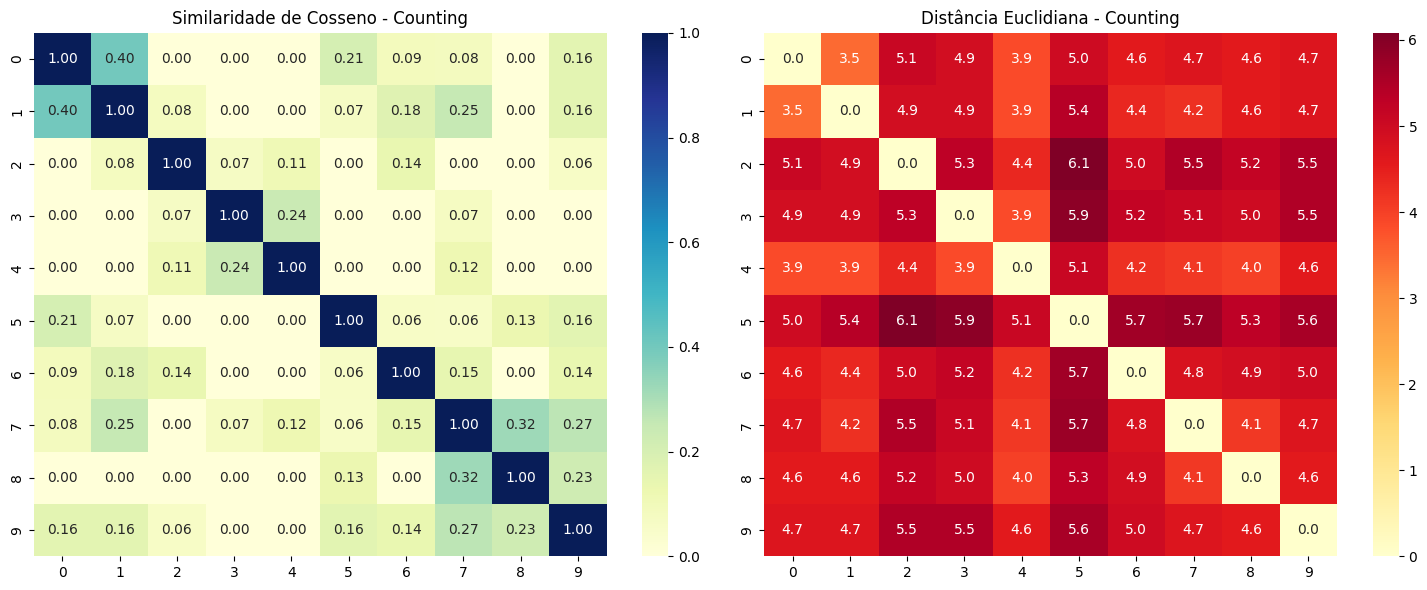

Matrizes para TF-IDF:


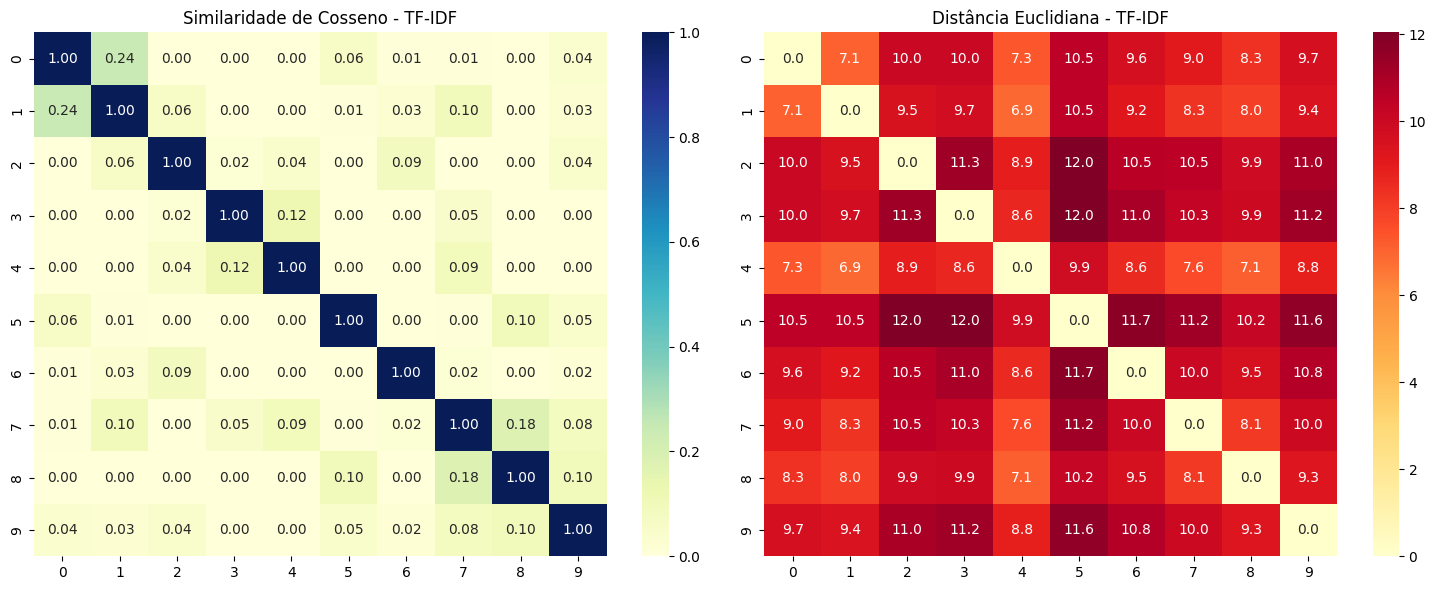

Matrizes para Word2Vec (Skip-gram Mean):


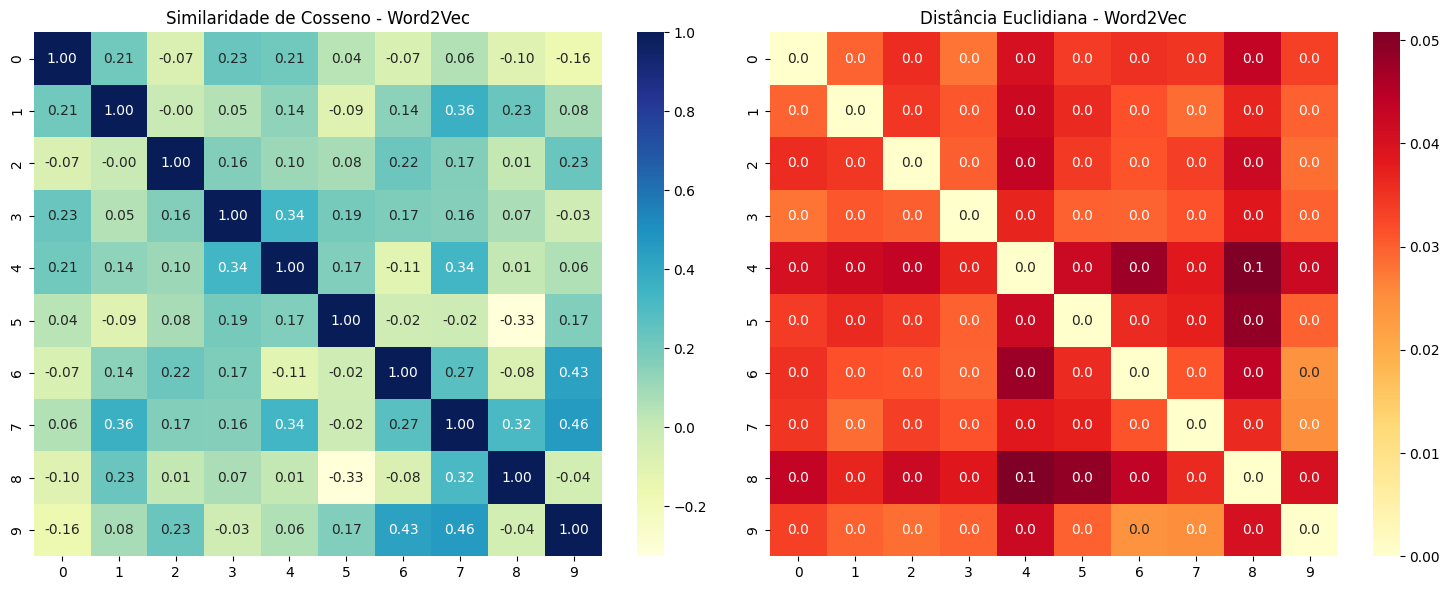

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances

# Redefinindo as funções auxiliares para garantir que estejam no escopo
def get_counting_vector(normalized_doc, vocabulary, word_to_idx):
    vector = np.zeros(len(vocabulary), dtype=int)
    for word in normalized_doc:
        if word in word_to_idx:
            vector[word_to_idx[word]] += 1
    return vector

def get_tfidf_vector(normalized_doc, vocabulary, word_to_idx, idf_dict):
    vector = np.zeros(len(vocabulary), dtype=float)
    counts = get_counting_vector(normalized_doc, vocabulary, word_to_idx)
    for word in set(normalized_doc):
        if word in word_to_idx:
            idx = word_to_idx[word]
            vector[idx] = counts[idx] * idf_dict[word]
    return vector

def get_doc_vector_w2v(doc, model):
    vectors = [model.wv[word] for word in doc if word in model.wv]
    return np.mean(vectors, axis=0) if vectors else np.zeros(model.vector_size)

# 1. Preparar as matrizes
counting_matrix = np.array([get_counting_vector(doc, vocabulary, word_to_idx) for doc in all_normalized_documents])
tfidf_matrix = np.array([get_tfidf_vector(doc, vocabulary, word_to_idx, idf_values) for doc in all_normalized_documents])
w2v_matrix = np.array([get_doc_vector_w2v(doc, model_skipgram) for doc in all_normalized_documents])

# 2. Função de plotagem
def plot_heatmaps(matrix, title_suffix):
    cos_sim = cosine_similarity(matrix)
    euc_dist = euclidean_distances(matrix)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    sns.heatmap(cos_sim, annot=True, fmt=".2f", cmap='YlGnBu', ax=ax1)
    ax1.set_title(f'Similaridade de Cosseno - {title_suffix}')

    sns.heatmap(euc_dist, annot=True, fmt=".1f", cmap='YlOrRd', ax=ax2)
    ax2.set_title(f'Distância Euclidiana - {title_suffix}')
    plt.tight_layout()
    plt.show()

print("Matrizes para Counting Vectors:")
plot_heatmaps(counting_matrix, "Counting")
print("Matrizes para TF-IDF:")
plot_heatmaps(tfidf_matrix, "TF-IDF")
print("Matrizes para Word2Vec (Skip-gram Mean):")
plot_heatmaps(w2v_matrix, "Word2Vec")